# Praktikum Kecerdasan Buatan – Week 5 / Sesi 3
## Klasterisasi dengan Hierarchical Clustering

**Institut Teknologi Del – 4233201 Kecerdasan Buatan**

### Teori singkat
**Hierarchical Clustering** adalah metode klasterisasi yang mengelompokkan data dalam bentuk **hierarki** (struktur pohon/dendrogram), dengan cara menggabungkan (*agglomerative*) atau memisahkan klaster secara bertahap berdasarkan jarak antar data.

Pendekatan yang dipakai di sini adalah **Agglomerative (bottom-up)**:
1. Setiap data mula-mula dianggap sebagai klaster tersendiri.
2. Pada tiap iterasi, dua klaster yang **paling dekat** digabung menjadi satu.
3. Diulang terus sampai semua data tergabung menjadi satu klaster besar.
4. Proses penggabungan ini divisualisasikan sebagai **dendrogram**.

Jarak antar klaster dihitung dengan metode **linkage**, beberapa yang umum:
- **Single linkage**: jarak minimum antar anggota dua klaster.
- **Complete linkage**: jarak maksimum antar anggota dua klaster.
- **Average linkage**: rata-rata jarak antar semua pasangan anggota dua klaster.

Berbeda dengan K-Means, Hierarchical Clustering **tidak memerlukan penentuan jumlah klaster K di awal** — jumlah klaster bisa ditentukan belakangan dengan "memotong" dendrogram pada ketinggian (jarak) tertentu.

---
## Percobaan 1 – Dataset sederhana

Digunakan 6 titik data sederhana (dua dimensi) untuk mempermudah pemahaman proses hierarchical clustering sebelum diterapkan ke data nyata.

In [1]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# 1. Dataset sederhana
data = np.array([
    [1.0, 1.0],  # a
    [1.5, 1.5],  # b
    [5.0, 5.0],  # c
    [3.0, 4.0],  # d
    [4.0, 4.0],  # e
    [3.0, 3.5]   # f
])

### 1.1 Menghitung Distance Matrix
`pdist` menghitung jarak Euclidean antar semua pasangan titik, lalu `squareform` mengubahnya menjadi **matriks jarak** berukuran 6×6 agar mudah dibaca (jarak titik ke dirinya sendiri = 0, matriks simetris).

In [2]:
# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
                            columns=['a', 'b', 'c', 'd', 'e', 'f'],
                            index=['a', 'b', 'c', 'd', 'e', 'f'])

# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)

=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


Dari matriks jarak terlihat:
- **a** dan **b** paling berdekatan (jarak ≈ 0,71) → kandidat pertama digabung.
- **d** dan **f** adalah pasangan paling dekat secara keseluruhan (jarak = 0,5).
- **c** relatif jauh dari titik-titik lain (jarak ke a ≈ 5,66, ke b ≈ 4,95), sehingga **c** kemungkinan akan bergabung paling akhir.

### 1.2 Hierarchical Clustering dengan Single Linkage
`linkage(data, method='single')` melakukan agglomerative clustering dengan **single linkage** (jarak minimum antar klaster), lalu hasilnya divisualisasikan sebagai **dendrogram**.

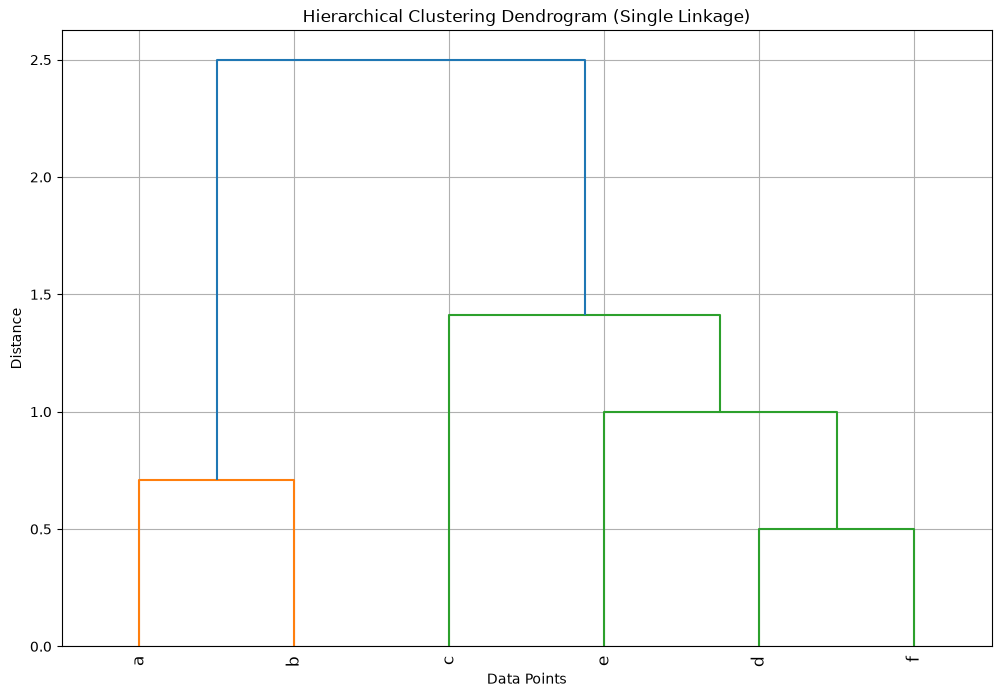

In [3]:
# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')

# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

**Interpretasi dendrogram Single Linkage:**
1. **d** dan **f** digabung pertama pada jarak **0,5** (paling dekat).
2. Klaster **{d,f}** lalu bergabung dengan **e** pada jarak **1,0**.
3. **a** dan **b** digabung pada jarak **≈0,71**, membentuk klaster **{a,b}**.
4. Klaster **{d,e,f}** bergabung dengan **c** pada jarak **≈1,41**.
5. Terakhir, klaster **{a,b}** bergabung dengan **{c,d,e,f}** pada jarak **2,5**, menyatukan semua titik menjadi satu klaster besar.

Jika dendrogram dipotong pada jarak sekitar 1,5–2, terbentuk **2 klaster utama**: **{a, b}** dan **{c, d, e, f}** — sesuai intuisi bahwa a,b berdekatan satu sama lain dan terpisah jauh dari gerombolan c,d,e,f.

---
## Percobaan 2 – Dataset Mall Customers

Selanjutnya Hierarchical Clustering diterapkan pada dataset nyata **Mall Customers**, dengan dua fitur penting: **Annual Income** dan **Spending Score**. Tujuannya adalah mengelompokkan pelanggan ke dalam klaster berdasarkan pola pengeluaran mereka.

In [4]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 2.1 Memilih fitur dan melakukan scaling
Diambil kolom **Annual Income (k\$)** dan **Spending Score (1-100)** (`iloc[:, [3, 4]]`). Karena Hierarchical Clustering berbasis jarak, data perlu **distandarisasi** terlebih dahulu dengan `StandardScaler` (mean = 0, std = 1) agar kedua fitur memiliki bobot yang setara dalam perhitungan jarak.

In [5]:
x = df.iloc[:, [3, 4]].values

In [6]:
from sklearn.preprocessing import StandardScaler

data_scaler = StandardScaler()

scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

### 2.2 Hierarchical Clustering dengan Complete Linkage
Kali ini digunakan **complete linkage** (jarak maksimum antar klaster), yang cenderung menghasilkan klaster yang lebih kompak dan seimbang dibanding single linkage.

In [7]:
from scipy.cluster.hierarchy import linkage, dendrogram

clustering = linkage(scaled_data, method="complete", metric="euclidean")

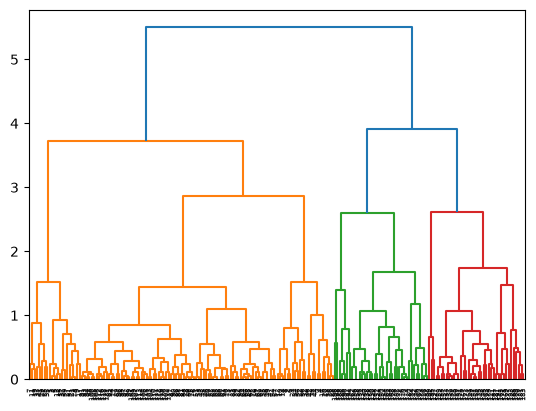

In [8]:
import matplotlib.pyplot as plt

dendrogram(clustering)
plt.show()

Dendrogram ini membagi data pelanggan menjadi **tiga kelompok utama** (ditandai warna oranye, hijau, dan merah). Pembagian ini membantu mengidentifikasi segmentasi pelanggan yang dapat digunakan untuk strategi pemasaran yang lebih tepat sasaran — misalnya pelanggan dengan pengeluaran rendah, sedang, dan tinggi, sehingga bisnis bisa memberikan penawaran yang lebih sesuai untuk tiap kelompok.

---
# Tugas

**Pada percobaan pertama dengan dataset sederhana, bandingkan hasil plot dendrogram single linkage dengan complete linkage dan average linkage.**

### Membuat dendrogram untuk ketiga metode linkage secara berdampingan

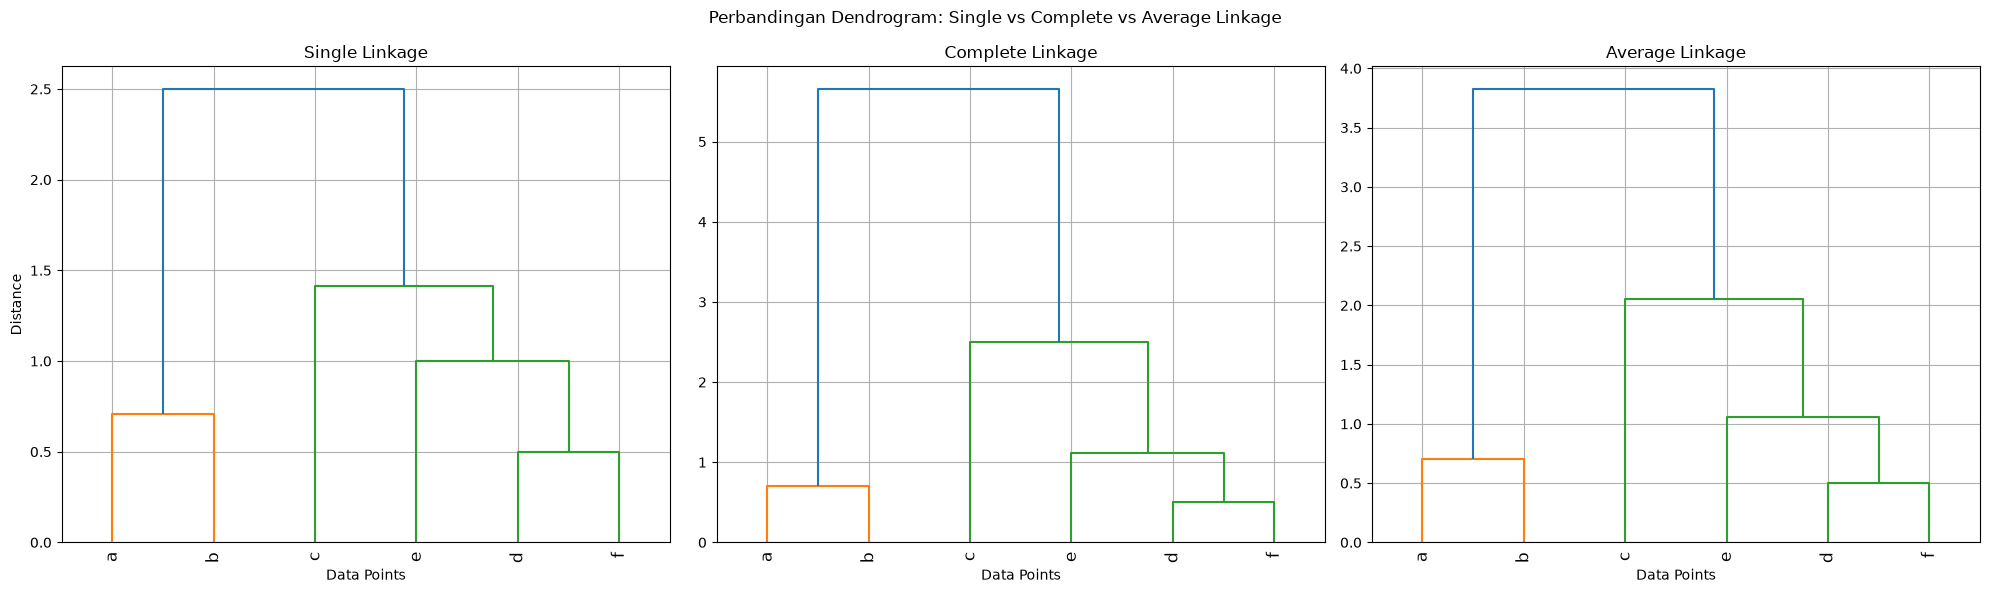

In [9]:
linked_single   = linkage(data, method='single')
linked_complete = linkage(data, method='complete')
linked_average  = linkage(data, method='average')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

dendrogram(linked_single, labels=['a','b','c','d','e','f'], leaf_rotation=90, ax=axes[0])
axes[0].set_title("Single Linkage")
axes[0].set_xlabel("Data Points")
axes[0].set_ylabel("Distance")
axes[0].grid(True)

dendrogram(linked_complete, labels=['a','b','c','d','e','f'], leaf_rotation=90, ax=axes[1])
axes[1].set_title("Complete Linkage")
axes[1].set_xlabel("Data Points")
axes[1].grid(True)

dendrogram(linked_average, labels=['a','b','c','d','e','f'], leaf_rotation=90, ax=axes[2])
axes[2].set_title("Average Linkage")
axes[2].set_xlabel("Data Points")
axes[2].grid(True)

plt.suptitle("Perbandingan Dendrogram: Single vs Complete vs Average Linkage")
plt.tight_layout()
plt.show()

### Melihat urutan dan jarak penggabungan (linkage matrix) untuk ketiga metode

In [10]:
for nama, Z in [("Single", linked_single), ("Complete", linked_complete), ("Average", linked_average)]:
    print(f"\n=== {nama} Linkage ===")
    print("cluster1  cluster2  jarak_gabung  jumlah_anggota")
    print(np.round(Z, 3))


=== Single Linkage ===
cluster1  cluster2  jarak_gabung  jumlah_anggota
[[3.    5.    0.5   2.   ]
 [0.    1.    0.707 2.   ]
 [4.    6.    1.    3.   ]
 [2.    8.    1.414 4.   ]
 [7.    9.    2.5   6.   ]]

=== Complete Linkage ===
cluster1  cluster2  jarak_gabung  jumlah_anggota
[[3.    5.    0.5   2.   ]
 [0.    1.    0.707 2.   ]
 [4.    6.    1.118 3.   ]
 [2.    8.    2.5   4.   ]
 [7.    9.    5.657 6.   ]]

=== Average Linkage ===
cluster1  cluster2  jarak_gabung  jumlah_anggota
[[3.    5.    0.5   2.   ]
 [0.    1.    0.707 2.   ]
 [4.    6.    1.059 3.   ]
 [2.    8.    2.05  4.   ]
 [7.    9.    3.826 6.   ]]


### Penjelasan dan perbandingan hasil

| Langkah penggabungan | Single Linkage | Complete Linkage | Average Linkage |
|---|---|---|---|
| 1 | d + f pada jarak **0,5** | d + f pada jarak **0,5** | d + f pada jarak **0,5** |
| 2 | a + b pada jarak **0,71** | a + b pada jarak **0,71** | a + b pada jarak **0,71** |
| 3 | {d,f} + e pada jarak **1,0** | {d,f} + e pada jarak **1,12** | {d,f} + e pada jarak **1,06** |
| 4 | {d,e,f} + c pada jarak **1,41** | {a,b} + c pada jarak **2,5** | {a,b} + {c} pada jarak **2,05** |
| 5 | {a,b} + {c,d,e,f} pada jarak **2,5** | {d,e,f,c} + {a,b} pada jarak **5,66** | {c,d,e,f} + {a,b} pada jarak **3,83** |

**Dua langkah pertama sama persis** di ketiga metode, karena pasangan terdekat (d,f) dan (a,b) tidak tergantung jenis linkage. Perbedaan mulai terlihat jelas setelah klaster mulai berisi lebih dari satu anggota:

- **Single Linkage** (jarak minimum antar klaster): cenderung menghasilkan rantai (*chaining*) — klaster bisa memanjang karena cukup satu pasang titik yang dekat agar dua klaster digabung. Di sini, klaster **{d,e,f}** cepat menyatu dengan **c** pada jarak kecil (1,41), karena jarak *terdekat* antara c dan anggota klaster {d,e,f} (yaitu c–e = 1,41) sudah cukup kecil, meskipun c sebenarnya jauh dari d dan f.
- **Complete Linkage** (jarak maksimum antar klaster): lebih "ketat" karena mempertimbangkan jarak *terjauh* antar anggota. Akibatnya, c baru bergabung dengan {d,e,f} pada jarak yang jauh lebih besar (5,66), bahkan **setelah** {a,b} bergabung dengan c (2,5) — struktur hierarkinya berbeda dari single linkage. Complete linkage cenderung menghasilkan klaster yang lebih **kompak dan bulat**.
- **Average Linkage** (rata-rata jarak semua pasangan): berada **di antara** single dan complete — tidak terlalu rentan *chaining* seperti single, tapi juga tidak seketat complete. Jarak penggabungan akhir (3,83) berada di antara nilai single (2,5) dan complete (5,66).

**Kesimpulan tugas:** Jika dendrogram dipotong untuk menghasilkan **2 klaster**, ketiga metode **sepakat** menghasilkan kelompok yang sama: **{a, b}** terpisah dari **{c, d, e, f}**, karena jarak a,b terhadap gerombolan c,d,e,f memang jauh di ketiga pengukuran. Namun, **urutan dan tinggi penggabungan di dalam gerombolan {c,d,e,f} berbeda** antar metode — khususnya kapan titik **c** (yang relatif terisolasi) bergabung dengan sisanya. Ini menunjukkan bahwa pemilihan metode linkage memengaruhi **struktur internal** dendrogram dan sebaiknya disesuaikan dengan karakteristik data: single linkage cocok untuk klaster berbentuk memanjang/tidak beraturan, sedangkan complete dan average linkage lebih cocok untuk klaster yang berbentuk kompak dan seimbang ukurannya — seperti yang terlihat pada hasil klasterisasi Mall Customers di atas yang menggunakan complete linkage.